In [1]:
#step 0 : import stategraph start and end and typedDict 
from langgraph.graph import StateGraph ,START,END #start and end are dummy nodes
from typing import TypedDict

c:\Users\asifn\.vscode\LangGraph\myenv\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [ ]:
# step 1 : any langgraph workflow -> define state 
class BMIState(TypedDict): #here BMIState is name of class to store state and it inherits from typedDict
    weight_kg:float
    height_m:float
    bmi:float
    bmi_lable:str        

In [ ]:
#python function to calculate bmi 
def calculate_bmi_pyfunc(state:BMIState)->BMIState:
    weight=state['weight_kg']
    height=state['height_m']

    bmi= weight/(height**2)
    state ['bmi'] = round(bmi,2)
    return state
   



In [ ]:
#python function to label bmi 
def label_bmi_pyfunc(state:BMIState)->BMIState:
    bmi=state['bmi']
    if bmi< 18.5:
        state['bmi_lable']='underweight'
    elif 18.5<=bmi<25:
        state['bmi_lable']='normal'
    elif 25<=bmi<30:
        state['bmi_lable']='overweight'
    else:
        state['bmi_lable']='obese'

    return state



In [ ]:
# step 2 : define our graph 
graph =StateGraph(BMIState) # first create an obj of class StateGraph() which is used to make graph    and in i/p put state of graph

#add nodes to our graph 
graph.add_node('calculate_BMI',calculate_bmi_pyfunc)
graph.add_node('label_bmi',label_bmi_pyfunc)

#add edges to our graph
graph.add_edge(START,'calculate_BMI') # 1st edge
graph.add_edge('calculate_BMI','label_bmi')#2nd edge
graph.add_edge('calculate_BMI',END) #3rd edge

#compile our graph
workflow = graph.compile()


In [6]:
#execute
initial_state={'weight_kg':80 ,'height_m':1.73}
final_state=workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'bmi_lable': 'overweight'}


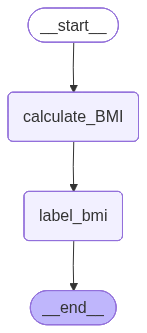

In [7]:
#to veiw our workflow ratta code from langgraph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
